In [ ]:
import os
import kagglehub
import shutil

# Download dataset
path = kagglehub.dataset_download("briscdataset/brisc2025")
print("Downloaded dataset path:", path)

# Copy dataset to /content for visibility in Colab file explorer
dest_path = "/content/brisc2025"
if not os.path.exists(dest_path):
    shutil.copytree(path, dest_path)

print("Dataset is now visible in Colab at:", dest_path)


Using Colab cache for faster access to the 'brisc2025' dataset.
Downloaded dataset path: /kaggle/input/brisc2025
Dataset is now visible in Colab at: /content/brisc2025


In [ ]:

import os
import shutil
from glob import glob
from PIL import Image
import numpy as np

# -----------------------------
# 1) CONFIG
# -----------------------------
BASE = "/content/brisc2025/brisc2025"
DEST = "/content/pituitary_vs_normal"

CLASSIF = os.path.join(BASE, "classification_task")   # has no_tumor images
SEG = os.path.join(BASE, "segmentation_task")         # has images + masks

IMG_EXTS = (".jpg", ".jpeg", ".png")                  # allowed image extensions

# -----------------------------
# 2) MAKE DESTINATION TREE
# -----------------------------
def make_dest_tree(dest_root):
    for split in ["train", "test"]:
        for kind in ["images", "masks"]:
            for cls in ["normal", "pituitary"]:
                os.makedirs(os.path.join(dest_root, split, kind, cls), exist_ok=True)

make_dest_tree(DEST)

# -----------------------------
# 3) UTILS
# -----------------------------
def save_blank_mask_like(image_path, save_path_png):
    """Create a single-channel all-zero mask with same HxW as image_path."""
    img = Image.open(image_path)
    img = img.convert("L")   # grayscale for shape only
    w, h = img.size
    blank = Image.fromarray(np.zeros((h, w), dtype=np.uint8))  # HxW
    os.makedirs(os.path.dirname(save_path_png), exist_ok=True)
    blank.save(save_path_png)

def print_counts(title, dest_root):
    def count_files(p):
        return len([f for f in glob(os.path.join(p, "*")) if os.path.isfile(f)])
    print(f"\n== {title} ==")
    for split in ["train", "test"]:
        n_img_norm = count_files(os.path.join(dest_root, split, "images", "normal"))
        n_img_pit  = count_files(os.path.join(dest_root, split, "images", "pituitary"))
        n_msk_norm = count_files(os.path.join(dest_root, split, "masks", "normal"))
        n_msk_pit  = count_files(os.path.join(dest_root, split, "masks", "pituitary"))
        print(f"{split.upper()}:  images → normal={n_img_norm}, pituitary={n_img_pit} | "
              f"masks → normal={n_msk_norm}, pituitary={n_msk_pit}")

def safe_copy(src, dst):
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    shutil.copy2(src, dst)

# -----------------------------
# 4) COPY NORMALS (classification → normal)
#    + create blank masks
# -----------------------------
def copy_normals_from_classification(split):
    src_dir = os.path.join(CLASSIF, split, "no_tumor")
    dst_img_dir = os.path.join(DEST, split, "images", "normal")
    dst_msk_dir = os.path.join(DEST, split, "masks", "normal")

    if not os.path.isdir(src_dir):
        print(f"WARNING: normal source folder not found: {src_dir}")
        return 0

    copied = 0
    files = sorted([f for f in glob(os.path.join(src_dir, "*")) if f.lower().endswith(IMG_EXTS)])
    for i, img_path in enumerate(files, 1):
        img_name = os.path.basename(img_path)
        dst_img = os.path.join(dst_img_dir, img_name)
        safe_copy(img_path, dst_img)

        # create blank mask (.png) using image size
        mask_name = os.path.splitext(img_name)[0] + ".png"
        dst_mask = os.path.join(dst_msk_dir, mask_name)
        save_blank_mask_like(img_path, dst_mask)

        copied += 1
        if i % 200 == 0:
            print(f"[{split}] normal copied: {i}")

    print(f"[{split}] normal total copied: {copied}")
    return copied

# -----------------------------
# 5) COPY PITUITARY (segmentation → pituitary)
#    filter filenames containing "_pi_"
# -----------------------------
def copy_pituitary_from_segmentation(split):
    seg_img_dir = os.path.join(SEG, split, "images")
    seg_msk_dir = os.path.join(SEG, split, "masks")

    dst_img_dir = os.path.join(DEST, split, "images", "pituitary")
    dst_msk_dir = os.path.join(DEST, split, "masks", "pituitary")

    if not os.path.isdir(seg_img_dir) or not os.path.isdir(seg_msk_dir):
        print(f"WARNING: segmentation paths missing: {seg_img_dir} or {seg_msk_dir}")
        return 0

    # Only pituitary images: filenames contain "_pi_"
    img_files = sorted([f for f in glob(os.path.join(seg_img_dir, "*")) if f.lower().endswith(IMG_EXTS)])
    pit_files = [f for f in img_files if "_pi_" in os.path.basename(f)]

    copied = 0
    missing_masks = 0

    for i, img_path in enumerate(pit_files, 1):
        img_name = os.path.basename(img_path)
        stem, ext = os.path.splitext(img_name)

        # masks are usually .png with identical stem
        candidate_masks = [
            os.path.join(seg_msk_dir, stem + ".png"),
            os.path.join(seg_msk_dir, stem + ext)  # fallback if same ext
        ]
        mask_path = None
        for cm in candidate_masks:
            if os.path.exists(cm):
                mask_path = cm
                break

        if mask_path is None:
            missing_masks += 1
            # Skip images with no matching mask
            # (Safer for segmentation training)
            continue

        # Copy both
        safe_copy(img_path, os.path.join(dst_img_dir, img_name))
        safe_copy(mask_path, os.path.join(dst_msk_dir, os.path.basename(mask_path)))
        copied += 1

        if i % 200 == 0:
            print(f"[{split}] pituitary processed: {i} (copied so far: {copied})")

    if missing_masks > 0:
        print(f"[{split}] pituitary had {missing_masks} images with missing masks (skipped).")
    print(f"[{split}] pituitary total copied: {copied}")
    return copied

# -----------------------------
# 6) RUN (train + test)
# -----------------------------
print("Building pituitary_vs_normal dataset...")
norm_train = copy_normals_from_classification("train")
norm_test  = copy_normals_from_classification("test")

pit_train = copy_pituitary_from_segmentation("train")
pit_test  = copy_pituitary_from_segmentation("test")

print_counts("COPY SUMMARY", DEST)

# -----------------------------
# 7) OPTIONAL: show a tiny tree
# -----------------------------
def list_some(dest_root, n=5):
    print("\nSample files:")
    for split in ["train", "test"]:
        for cls in ["normal", "pituitary"]:
            imgs = sorted(glob(os.path.join(dest_root, split, "images", cls, "*")))[:n]
            msks = sorted(glob(os.path.join(dest_root, split, "masks", cls, "*")))[:n]
            print(f"{split}/{cls}/images (first {len(imgs)}):")
            for p in imgs:
                print("  ", os.path.basename(p))
            print(f"{split}/{cls}/masks  (first {len(msks)}):")
            for p in msks:
                print("  ", os.path.basename(p))

list_some(DEST, n=3)

print("\n✅ Done. Final dataset at:", DEST)


Building pituitary_vs_normal dataset...
[train] normal copied: 200
[train] normal copied: 400
[train] normal copied: 600
[train] normal copied: 800
[train] normal copied: 1000
[train] normal total copied: 1067
[test] normal total copied: 140
[train] pituitary processed: 200 (copied so far: 200)
[train] pituitary processed: 400 (copied so far: 400)
[train] pituitary processed: 600 (copied so far: 600)
[train] pituitary processed: 800 (copied so far: 800)
[train] pituitary processed: 1000 (copied so far: 1000)
[train] pituitary processed: 1200 (copied so far: 1200)
[train] pituitary processed: 1400 (copied so far: 1400)
[train] pituitary total copied: 1457
[test] pituitary processed: 200 (copied so far: 200)
[test] pituitary total copied: 300

== COPY SUMMARY ==
TRAIN:  images → normal=1067, pituitary=1457 | masks → normal=1067, pituitary=1457
TEST:  images → normal=140, pituitary=300 | masks → normal=140, pituitary=300

Sample files:
train/normal/images (first 3):
   brisc2025_train_024

In [ ]:
!pip -q install monai[nibabel,ignite,tqdm] torchmetrics -U


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 113.7 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Train: 2524 | Val: 440


Epoch 1/20 [Train]: 100%|██████████| 631/631 [02:33<00:00,  4.12it/s, loss=0.3659]


Epoch 1 Train Loss: 0.4594
Epoch 1 Val Loss: 0.3616 | Val Dice: 0.7130 | Val Acc: 0.9782
New best model saved with Dice: 0.7130


Epoch 2/20 [Train]: 100%|██████████| 631/631 [02:36<00:00,  4.02it/s, loss=0.3373]


...

Epoch 18 Train Loss: 0.2792
Epoch 18 Val Loss: 0.2422 | Val Dice: 0.8261 | Val Acc: 0.9881


Epoch 19/20 [Train]: 100%|██████████| 631/631 [02:36<00:00,  4.03it/s, loss=0.3237]


Epoch 19 Train Loss: 0.2781
Epoch 19 Val Loss: 0.2410 | Val Dice: 0.8263 | Val Acc: 0.9886


Epoch 20/20 [Train]: 100%|██████████| 631/631 [02:33<00:00,  4.10it/s, loss=0.2830]


Epoch 20 Train Loss: 0.2769
Epoch 20 Val Loss: 0.2396 | Val Dice: 0.8282 | Val Acc: 0.9894


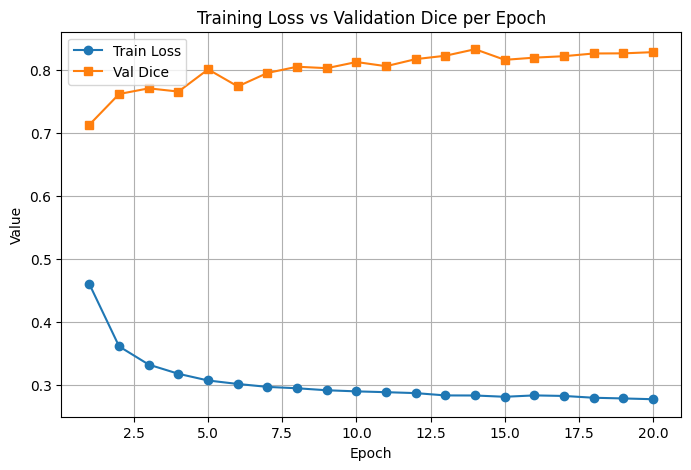

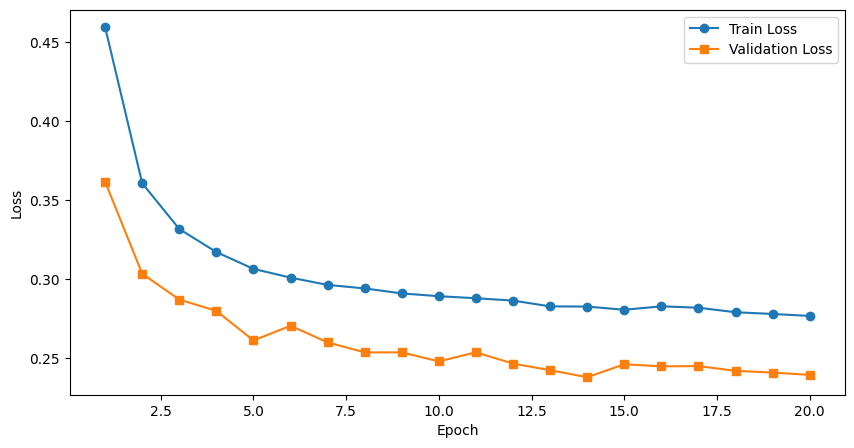

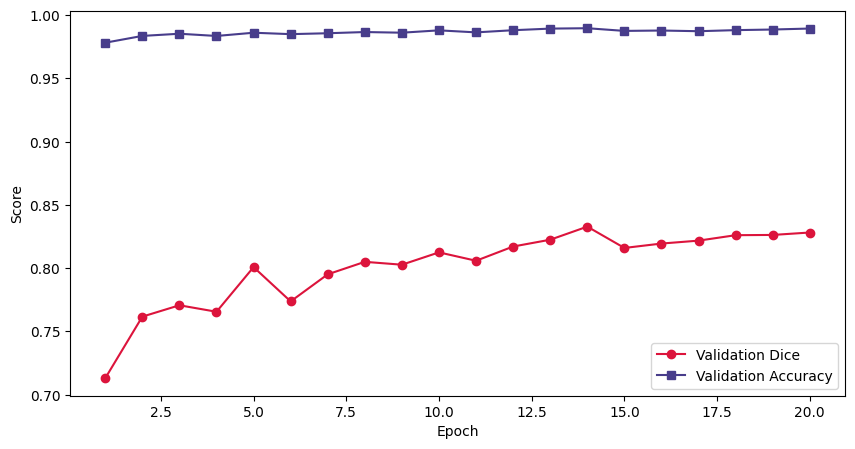


Loading best model for final evaluation...


Final Evaluation: 100%|██████████| 110/110 [00:09<00:00, 11.21it/s]


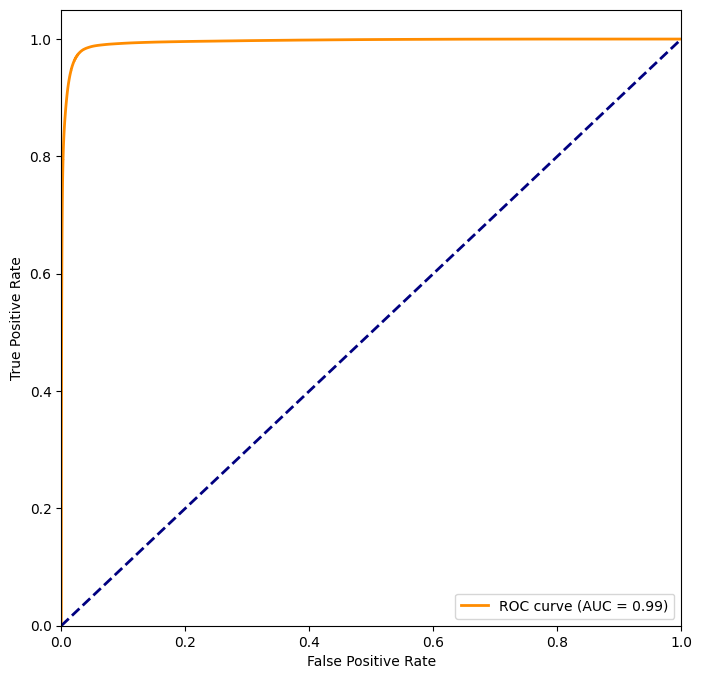

In [ ]:
# @title
# =========================================================
# 1. IMPORTS
# =========================================================
import os, glob
import numpy as np
import torch
from torch.utils.data import DataLoader
from monai.networks.nets import SwinUNETR
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd,
    ResizeWithPadOrCropd, RandFlipd, RandRotate90d, EnsureTyped, MapTransform
)
from monai.data import CacheDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

import cv2
import torch.nn as nn
from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix, roc_curve, auc

# =========================================================
# 2. CONFIG
# =========================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
BATCH_SIZE = 4   # SwinUNETR is memory heavy
NUM_WORKERS = 0
NUM_EPOCHS = 20
LR = 1e-4
TARGET_CHANNELS = 3  # final input channels for model

# =========================================================
# 3. DATASET FILES
# =========================================================
root_dir = "/content/pituitary_vs_normal"

def get_files(split):
    img_paths, mask_paths = [], []
    for cls in ["normal", "pituitary"]:
        imgs = sorted(glob.glob(os.path.join(root_dir, split, "images", cls, "*.*")))
        masks = sorted(glob.glob(os.path.join(root_dir, split, "masks", cls, "*.*")))
        img_paths.extend(imgs)
        mask_paths.extend(masks)
    return [{"image": i, "mask": m} for i, m in zip(img_paths, mask_paths)]

train_files = get_files("train")
val_files   = get_files("test")
print(f"Train: {len(train_files)} | Val: {len(val_files)}")

# =========================================================
# 4. MASK TRANSFORM FIX
# =========================================================
class Mask255To1(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            d[key] = (d[key] > 0).float()
        return d

mask_transform = Mask255To1(keys=["mask"])

# =========================================================
# 5. ENSURE FIXED IMAGE CHANNELS (1->TARGET_CHANNELS, 9->3)
# =========================================================
class EnsureNCChannels(MapTransform):
    def __init__(self, keys, target_channels=3):
        super().__init__(keys)
        self.target_channels = target_channels

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            x = d[key]
            c, h, w = x.shape
            if c == self.target_channels:
                continue
            elif c < self.target_channels:
                repeats = self.target_channels // c + 1
                x = x.repeat(repeats, 1, 1)[:self.target_channels]
            else:  # c > target_channels
                x = x[:self.target_channels]
            d[key] = x
        return d

ensure_channels = EnsureNCChannels(keys=["image"], target_channels=TARGET_CHANNELS)

# =========================================================
# 6. TRANSFORMS
# =========================================================
train_transforms = Compose([
    LoadImaged(keys=["image", "mask"]),
    EnsureChannelFirstd(keys=["image", "mask"]),
    ensure_channels,
    ScaleIntensityd(keys=["image"]),
    ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(IMG_SIZE, IMG_SIZE)),
    RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=1),
    RandRotate90d(keys=["image", "mask"], prob=0.2, max_k=3),
    mask_transform,
    EnsureTyped(keys=["image", "mask"], track_meta=False),
])

val_transforms = Compose([
    LoadImaged(keys=["image", "mask"]),
    EnsureChannelFirstd(keys=["image", "mask"]),
    ensure_channels,
    ScaleIntensityd(keys=["image"]),
    ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(IMG_SIZE, IMG_SIZE)),
    mask_transform,
    EnsureTyped(keys=["image", "mask"], track_meta=False),
])

# =========================================================
# 7. DATASETS & LOADERS
# =========================================================
train_ds = CacheDataset(train_files, transform=train_transforms, cache_rate=1.0, num_workers=NUM_WORKERS)
val_ds   = CacheDataset(val_files, transform=val_transforms, cache_rate=1.0, num_workers=NUM_WORKERS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# =========================================================
# 8. MODEL, LOSS, OPTIMIZER
# =========================================================
model = SwinUNETR(
    in_channels=TARGET_CHANNELS,
    out_channels=1,
    feature_size=48,
    use_checkpoint=True,
    spatial_dims=2
).to(DEVICE)
dice_loss = DiceLoss(sigmoid=True)
bce_loss  = nn.BCEWithLogitsLoss()
optimizer   = torch.optim.Adam(model.parameters(), lr=LR)
dice_metric = DiceMetric(include_background=False, reduction="mean")

# =========================================================
# 9. TRAINING LOOP WITH TRACKING
# =========================================================
best_dice = 0.0
train_losses = []
val_losses = [] # <-- NEW: For tracking validation loss
val_dices = []
val_accuracies = [] # <-- NEW: For tracking validation accuracy

for epoch in range(NUM_EPOCHS):
    # ---------------- TRAIN ----------------
    model.train()
    epoch_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for batch in pbar:
        images, masks = batch["image"].to(DEVICE), batch["mask"].to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = 0.5*dice_loss(outputs, masks) + 0.5*bce_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_train_loss = epoch_loss / max(1, len(train_loader))
    train_losses.append(avg_train_loss)
    print(f"Epoch {epoch+1} Train Loss: {avg_train_loss:.4f}")

    # ---------------- VALIDATION ----------------
    model.eval()
    epoch_val_loss = 0 # <-- NEW
    epoch_val_acc = 0 # <-- NEW

    with torch.no_grad():
        for batch in val_loader:
            images, masks = batch["image"].to(DEVICE), batch["mask"].to(DEVICE)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            # <-- NEW: Calculate validation loss
            val_loss = 0.5 * dice_loss(outputs, masks) + 0.5 * bce_loss(outputs, masks)
            epoch_val_loss += val_loss.item()

            # <-- NEW: Calculate pixel-wise accuracy
            acc = (preds == masks).float().mean().item()
            epoch_val_acc += acc

            # Calculate Dice score
            dice_metric(y_pred=preds, y=masks)

    # <-- Aggregate and store metrics for the epoch -->
    # Dice Score
    avg_dice = dice_metric.aggregate().item()
    dice_metric.reset()
    val_dices.append(avg_dice)

    # Validation Loss
    avg_val_loss = epoch_val_loss / max(1, len(val_loader))
    val_losses.append(avg_val_loss)

    # Accuracy
    avg_val_acc = epoch_val_acc / max(1, len(val_loader))
    val_accuracies.append(avg_val_acc)

    print(f"Epoch {epoch+1} Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_dice:.4f} | Val Acc: {avg_val_acc:.4f}")


    # ---------------- SAVE BEST MODEL ----------------
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), "best_swin_model.pth")
        print(f"New best model saved with Dice: {best_dice:.4f}")

# =========================================================
# 10. PLOT TRAIN LOSS VS VAL DICE (Original Plot)
# =========================================================
plt.figure(figsize=(8,5))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, NUM_EPOCHS+1), val_dices, label="Val Dice", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Loss vs Validation Dice per Epoch")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 11. NEW: PLOT TRAINING VS VALIDATION LOSS
# =========================================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label="Validation Loss", marker='s')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(False)
plt.savefig("SWINUNETR_trainig_vs_valid.png", dpi=300, bbox_inches="tight")

plt.show()


# =========================================================
# 12. NEW: PLOT VALIDATION DICE AND ACCURACY
# =========================================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), val_dices, label="Validation Dice", marker='o', color='crimson')
plt.plot(range(1, NUM_EPOCHS + 1), val_accuracies, label="Validation Accuracy", marker='s', color='darkslateblue')

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(False)
plt.savefig("SWINUNETR_Accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

# =========================================================
# 13. NEW: FINAL EVALUATION AND ROC CURVE
# =========================================================
print("\nLoading best model for final evaluation...")
model.load_state_dict(torch.load("best_swin_model.pth"))
model.eval()

y_true_all = []
y_pred_scores_all = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Final Evaluation"):
        images, masks = batch["image"].to(DEVICE), batch["mask"].to(DEVICE)
        outputs = model(images)
        pred_scores = torch.sigmoid(outputs)

        y_true_all.extend(masks.cpu().numpy().flatten())
        y_pred_scores_all.extend(pred_scores.cpu().numpy().flatten())

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_all, y_pred_scores_all)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc="lower right")
plt.grid(False)
plt.savefig("SWINUNETR_ROC.png", dpi=300, bbox_inches="tight")

plt.show()


#TEST


Train: 2524 | Val: 440


Epoch 1/20 [Train]: 100%|██████████| 421/421 [02:13<00:00,  3.16it/s, loss=0.4459, acc=0.9676]


Epoch 1 Train Loss: 0.5051 | Train Acc: 0.9599
Epoch 1 Val Loss: 0.4085 | Val Dice: 0.6778 | Val Acc: 0.9717
New best model saved with Dice: 0.6778


Epoch 2/20 [Train]: 100%|██████████| 421/421 [02:14<00:00,  3.14it/s, loss=0.4642, acc=0.9928]


Epoch 2 Train Loss: 0.3923 | Train Acc: 0.9785
Epoch 2 Val Loss: 0.3532 | Val Dice: 0.6833 | Val Acc: 0.9736
New best model saved with Dice: 0.6833


...

Epoch 18 Train Loss: 0.2788 | Train Acc: 0.9894
Epoch 18 Val Loss: 0.2403 | Val Dice: 0.8245 | Val Acc: 0.9888


Epoch 19/20 [Train]: 100%|██████████| 421/421 [02:14<00:00,  3.14it/s, loss=0.3954, acc=0.9933]


Epoch 19 Train Loss: 0.2788 | Train Acc: 0.9892
Epoch 19 Val Loss: 0.2427 | Val Dice: 0.8192 | Val Acc: 0.9880


Epoch 20/20 [Train]: 100%|██████████| 421/421 [02:14<00:00,  3.14it/s, loss=0.3339, acc=0.8546]


Epoch 20 Train Loss: 0.2777 | Train Acc: 0.9894
Epoch 20 Val Loss: 0.2452 | Val Dice: 0.8168 | Val Acc: 0.9877


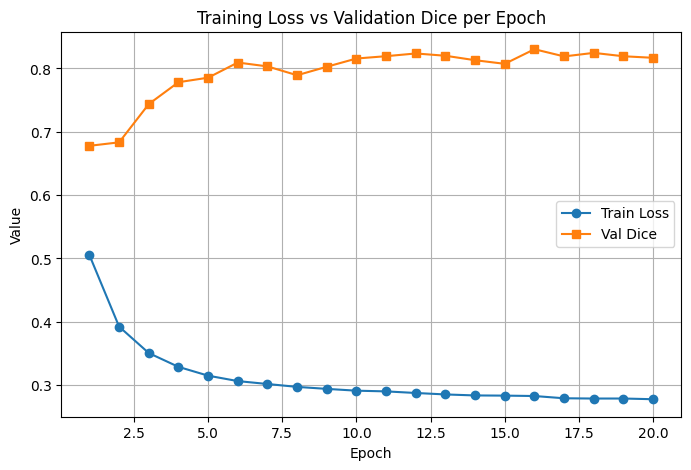

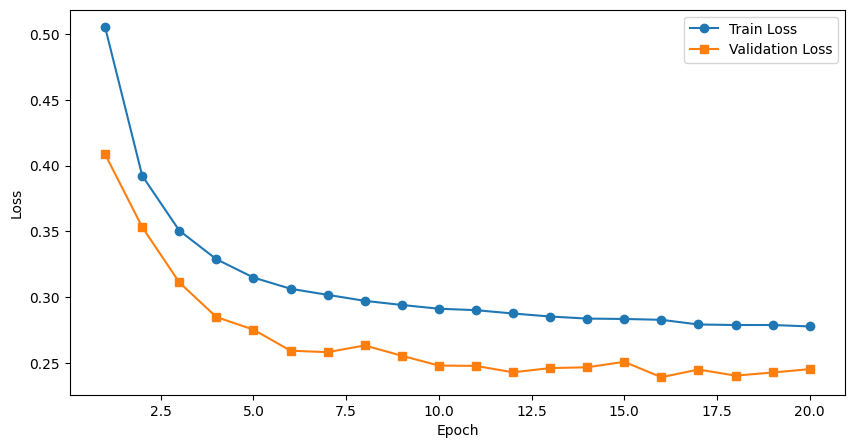

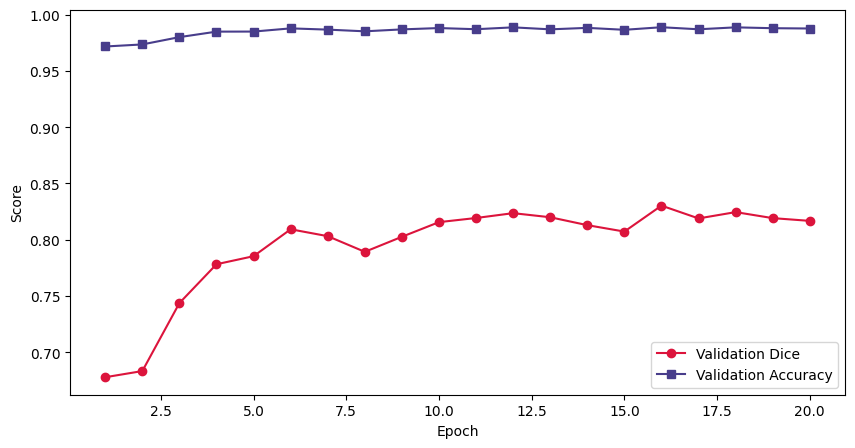


Loading best model for final evaluation...


Final Evaluation: 100%|██████████| 74/74 [00:09<00:00,  8.14it/s]


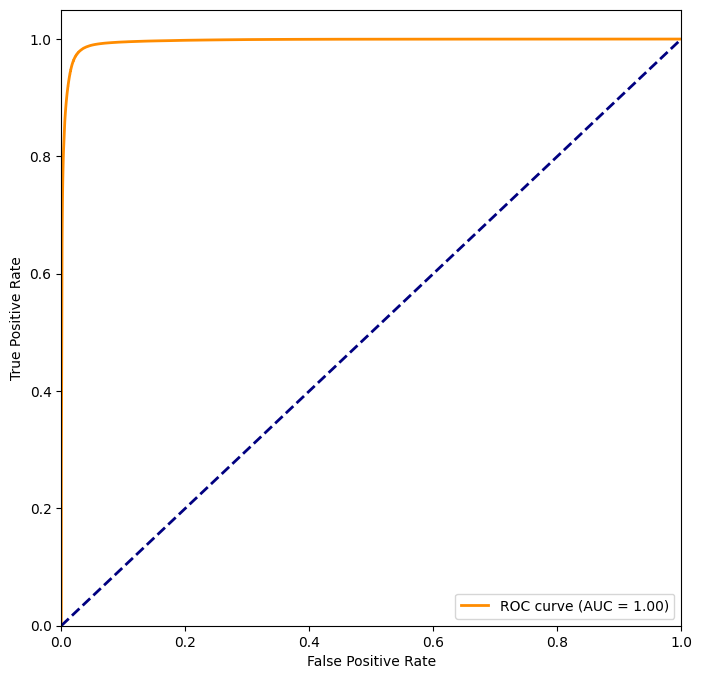

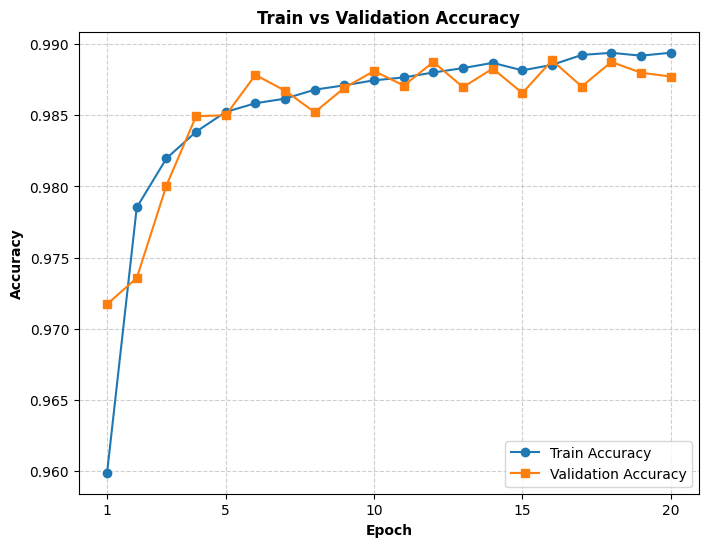

In [ ]:
# =========================================================
# 1. IMPORTS
# =========================================================
import os, glob
import numpy as np
import torch
from torch.utils.data import DataLoader
from monai.networks.nets import SwinUNETR
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd,
    ResizeWithPadOrCropd, RandFlipd, RandRotate90d, EnsureTyped, MapTransform
)
from monai.data import CacheDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

import cv2
import torch.nn as nn
from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix, roc_curve, auc

# =========================================================
# 2. CONFIG
# =========================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
BATCH_SIZE = 6   # SwinUNETR is memory heavy
NUM_WORKERS = 0
NUM_EPOCHS = 20
LR = 1e-4
TARGET_CHANNELS = 3  # final input channels for model

# =========================================================
# 3. DATASET FILES
# =========================================================
root_dir = "/content/pituitary_vs_normal"

def get_files(split):
    img_paths, mask_paths = [], []
    for cls in ["normal", "pituitary"]:
        imgs = sorted(glob.glob(os.path.join(root_dir, split, "images", cls, "*.*")))
        masks = sorted(glob.glob(os.path.join(root_dir, split, "masks", cls, "*.*")))
        img_paths.extend(imgs)
        mask_paths.extend(masks)
    return [{"image": i, "mask": m} for i, m in zip(img_paths, mask_paths)]

train_files = get_files("train")
val_files   = get_files("test")
print(f"Train: {len(train_files)} | Val: {len(val_files)}")

# =========================================================
# 4. MASK TRANSFORM FIX
# =========================================================
class Mask255To1(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            d[key] = (d[key] > 0).float()
        return d

mask_transform = Mask255To1(keys=["mask"])

# =========================================================
# 5. ENSURE FIXED IMAGE CHANNELS (1->TARGET_CHANNELS, 9->3)
# =========================================================
class EnsureNCChannels(MapTransform):
    def __init__(self, keys, target_channels=3):
        super().__init__(keys)
        self.target_channels = target_channels

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            x = d[key]
            c, h, w = x.shape
            if c == self.target_channels:
                continue
            elif c < self.target_channels:
                repeats = self.target_channels // c + 1
                x = x.repeat(repeats, 1, 1)[:self.target_channels]
            else:  # c > target_channels
                x = x[:self.target_channels]
            d[key] = x
        return d

ensure_channels = EnsureNCChannels(keys=["image"], target_channels=TARGET_CHANNELS)

# =========================================================
# 6. TRANSFORMS
# =========================================================
train_transforms = Compose([
    LoadImaged(keys=["image", "mask"]),
    EnsureChannelFirstd(keys=["image", "mask"]),
    ensure_channels,
    ScaleIntensityd(keys=["image"]),
    ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(IMG_SIZE, IMG_SIZE)),
    RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=1),
    RandRotate90d(keys=["image", "mask"], prob=0.2, max_k=3),
    mask_transform,
    EnsureTyped(keys=["image", "mask"], track_meta=False),
])

val_transforms = Compose([
    LoadImaged(keys=["image", "mask"]),
    EnsureChannelFirstd(keys=["image", "mask"]),
    ensure_channels,
    ScaleIntensityd(keys=["image"]),
    ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(IMG_SIZE, IMG_SIZE)),
    mask_transform,
    EnsureTyped(keys=["image", "mask"], track_meta=False),
])

# =========================================================
# 7. DATASETS & LOADERS
# =========================================================
train_ds = CacheDataset(train_files, transform=train_transforms, cache_rate=1.0, num_workers=NUM_WORKERS)
val_ds   = CacheDataset(val_files, transform=val_transforms, cache_rate=1.0, num_workers=NUM_WORKERS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# =========================================================
# 8. MODEL, LOSS, OPTIMIZER
# =========================================================
model = SwinUNETR(
    in_channels=TARGET_CHANNELS,
    out_channels=1,
    feature_size=48,
    use_checkpoint=True,
    spatial_dims=2
).to(DEVICE)
dice_loss = DiceLoss(sigmoid=True)
bce_loss  = nn.BCEWithLogitsLoss()
optimizer   = torch.optim.Adam(model.parameters(), lr=LR)
dice_metric = DiceMetric(include_background=False, reduction="mean")

# =========================================================
# 9. MODIFIED TRAINING LOOP WITH ACCURACY TRACKING
# =========================================================
best_dice = 0.0
train_losses = []
train_accuracies = [] # <-- MODIFIED: For tracking training accuracy
val_losses = []
val_dices = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):
    # ---------------- TRAIN ----------------
    model.train()
    epoch_loss = 0
    epoch_train_acc = 0 # <-- MODIFIED: Accumulator for training accuracy

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for batch in pbar:
        images, masks = batch["image"].to(DEVICE), batch["mask"].to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = 0.5*dice_loss(outputs, masks) + 0.5*bce_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        # <-- MODIFIED: Calculate and accumulate training accuracy for the batch
        with torch.no_grad():
            preds = (torch.sigmoid(outputs) > 0.5).float()
            acc = (preds == masks).float().mean().item()
            epoch_train_acc += acc

        pbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{acc:.4f}"}) # <-- MODIFIED: Display batch accuracy

    avg_train_loss = epoch_loss / max(1, len(train_loader))
    train_losses.append(avg_train_loss)

    # <-- MODIFIED: Calculate and store average training accuracy for the epoch
    avg_train_acc = epoch_train_acc / max(1, len(train_loader))
    train_accuracies.append(avg_train_acc)

    print(f"Epoch {epoch+1} Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f}")

    # ---------------- VALIDATION ----------------
    model.eval()
    epoch_val_loss = 0
    epoch_val_acc = 0

    with torch.no_grad():
        for batch in val_loader:
            images, masks = batch["image"].to(DEVICE), batch["mask"].to(DEVICE)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            val_loss = 0.5 * dice_loss(outputs, masks) + 0.5 * bce_loss(outputs, masks)
            epoch_val_loss += val_loss.item()

            acc = (preds == masks).float().mean().item()
            epoch_val_acc += acc

            dice_metric(y_pred=preds, y=masks)

    # Aggregate and store metrics for the epoch
    avg_dice = dice_metric.aggregate().item()
    dice_metric.reset()
    val_dices.append(avg_dice)

    avg_val_loss = epoch_val_loss / max(1, len(val_loader))
    val_losses.append(avg_val_loss)

    avg_val_acc = epoch_val_acc / max(1, len(val_loader))
    val_accuracies.append(avg_val_acc)

    print(f"Epoch {epoch+1} Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_dice:.4f} | Val Acc: {avg_val_acc:.4f}")


    # ---------------- SAVE BEST MODEL ----------------
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), "best_swin_model.pth")
        print(f"New best model saved with Dice: {best_dice:.4f}")

# =========================================================
# 10. PLOT TRAIN LOSS VS VAL DICE (Original Plot)
# =========================================================
plt.figure(figsize=(8,5))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, NUM_EPOCHS+1), val_dices, label="Val Dice", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Loss vs Validation Dice per Epoch")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 11. NEW: PLOT TRAINING VS VALIDATION LOSS
# =========================================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label="Validation Loss", marker='s')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(False)
plt.savefig("SWINUNETR_trainig_vs_valid.png", dpi=300, bbox_inches="tight")

plt.show()


# =========================================================
# 12. NEW: PLOT VALIDATION DICE AND ACCURACY
# =========================================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), val_dices, label="Validation Dice", marker='o', color='crimson')
plt.plot(range(1, NUM_EPOCHS + 1), val_accuracies, label="Validation Accuracy", marker='s', color='darkslateblue')

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(False)
plt.savefig("SWINUNETR_Accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

# =========================================================
# 13. NEW: FINAL EVALUATION AND ROC CURVE
# =========================================================
print("\nLoading best model for final evaluation...")
model.load_state_dict(torch.load("best_swin_model.pth"))
model.eval()

y_true_all = []
y_pred_scores_all = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Final Evaluation"):
        images, masks = batch["image"].to(DEVICE), batch["mask"].to(DEVICE)
        outputs = model(images)
        pred_scores = torch.sigmoid(outputs)

        y_true_all.extend(masks.cpu().numpy().flatten())
        y_pred_scores_all.extend(pred_scores.cpu().numpy().flatten())

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_all, y_pred_scores_all)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc="lower right")
plt.grid(False)
plt.savefig("SWINUNETR_ROC.png", dpi=300, bbox_inches="tight")

plt.show()
# =========================================================
# 14. NEW: PLOT TRAIN VS VALIDATION ACCURACY
# =========================================================
plt.figure(figsize=(8, 6))

# Plot the accuracy curves
plt.plot(range(1, NUM_EPOCHS + 1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), val_accuracies, label="Validation Accuracy", marker='s')

# Set bold labels for the axes
plt.xlabel("Epoch", fontweight='bold')
plt.ylabel("Accuracy", fontweight='bold')

# Set a title for the plot
plt.title("Train vs Validation Accuracy", fontweight='bold')

# Reduce the number of ticks on the x-axis
plt.xticks([1, 5, 10, 15, 20])

# Move legend to bottom-right
plt.legend(loc="lower right")

plt.grid(True, linestyle='--', alpha=0.6)

# Save the figure as a high-resolution PDF
plt.savefig("SWINUNETR_Train_vs_Val_Accuracy.pdf", dpi=300, format='pdf', bbox_inches="tight")

plt.show()


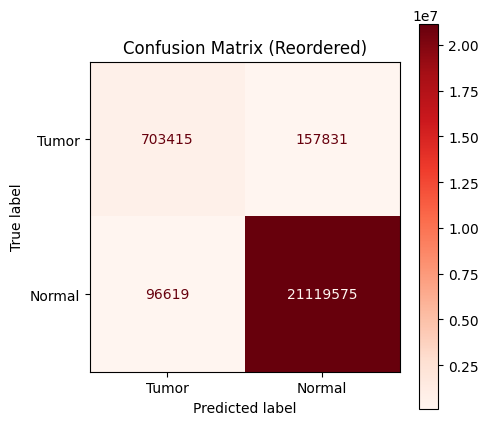

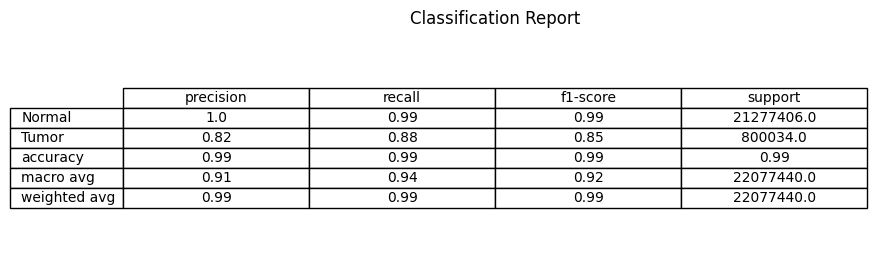

Upload original image:


Saving brisc2025_train_03544_pi_ax_t1.jpg to brisc2025_train_03544_pi_ax_t1.jpg
Upload ground truth mask:


Saving brisc2025_train_03544_pi_ax_t1.png to brisc2025_train_03544_pi_ax_t1.png


/tmp/ipython-input-1524221161.py:113: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_tensor = torch.tensor(img, dtype=torch.float).unsqueeze(0).to(DEVICE)


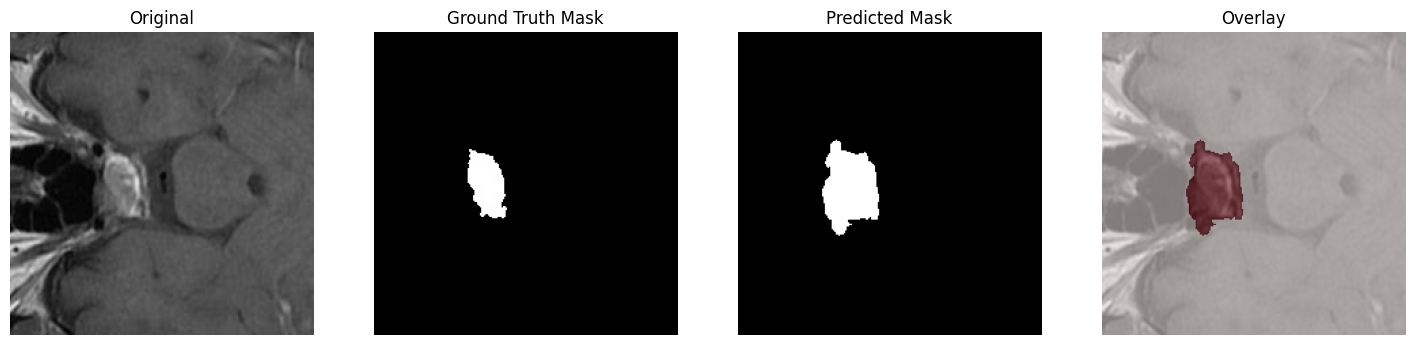

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
import cv2
import pandas as pd
from monai.transforms import LoadImage, EnsureChannelFirst, ScaleIntensity, ResizeWithPadOrCrop, Compose
from google.colab import files

# -------------------------------------------------
# 1. Load trained weights
# -------------------------------------------------
model.load_state_dict(torch.load("/content/best_swin_model.pth", map_location=DEVICE))
model.eval()

# -------------------------------------------------
# 2. Run inference on validation/test set
# -------------------------------------------------
y_true = []
y_pred = []

with torch.no_grad():
    for batch in val_loader:   # DataLoader for validation
        images = batch["image"].to(DEVICE)   # [B, C, H, W]
        masks  = batch["mask"].to(DEVICE)    # [B, 1, H, W]

        outputs = model(images)              # raw logits
        probs   = torch.sigmoid(outputs)     # probabilities
        preds   = (probs > 0.5).float()      # binary mask

        # Flatten for confusion matrix
        y_true.extend(masks.cpu().numpy().ravel())
        y_pred.extend(preds.cpu().numpy().ravel())

# -------------------------------------------------
# 3. Confusion Matrix (reordered)
# -------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

# Extract values
TP = cm[1,1]
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]

# Reorder into requested format
cm_custom = np.array([[TP, FP],
                      [FN, TN]])

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_custom,
                              display_labels=["Tumor", "Normal"])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(cmap=plt.cm.Reds, ax=ax, values_format="d")
plt.title("Confusion Matrix (Reordered)")
plt.show()

# -------------------------------------------------
# 4. Extra metrics table (Precision/Recall/F1/Support)
# -------------------------------------------------
report = classification_report(y_true, y_pred,
                               target_names=["Normal", "Tumor"],
                               output_dict=True)

df_report = pd.DataFrame(report).transpose()
df_report = df_report.round(2)

# Display as table
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")
tbl = ax.table(cellText=np.round(df_report.values, 2),
               rowLabels=df_report.index,
               colLabels=df_report.columns,
               cellLoc='center',
               loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)
plt.title("Classification Report")
plt.show()

# -------------------------------------------------
# 5. Single Image Inference
# -------------------------------------------------
IMG_SIZE = 224  # Must match training

infer_img = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    ScaleIntensity(),
    ResizeWithPadOrCrop(spatial_size=(IMG_SIZE, IMG_SIZE)),
])

infer_mask = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    ResizeWithPadOrCrop(spatial_size=(IMG_SIZE, IMG_SIZE)),
])

print("Upload original image:")
uploaded_img = files.upload()
img_path = list(uploaded_img.keys())[0]

print("Upload ground truth mask:")
uploaded_mask = files.upload()
mask_path = list(uploaded_mask.keys())[0]

# Preprocess
img  = infer_img(img_path)
mask = infer_mask(mask_path)

img_tensor = torch.tensor(img, dtype=torch.float).unsqueeze(0).to(DEVICE)

# Predict mask
with torch.no_grad():
    output = model(img_tensor)
    pred_mask = (torch.sigmoid(output) > 0.5).float().cpu().squeeze().numpy()

# -------------------------------------------------
# 6. Visualization
# -------------------------------------------------
img_for_plot = np.transpose(img, (1,2,0))  # CHW → HWC

plt.figure(figsize=(18,6))

plt.subplot(1,4,1)
plt.imshow(img_for_plot, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(img_for_plot, cmap="gray")
plt.imshow(pred_mask, cmap="Reds", alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.show()


#area

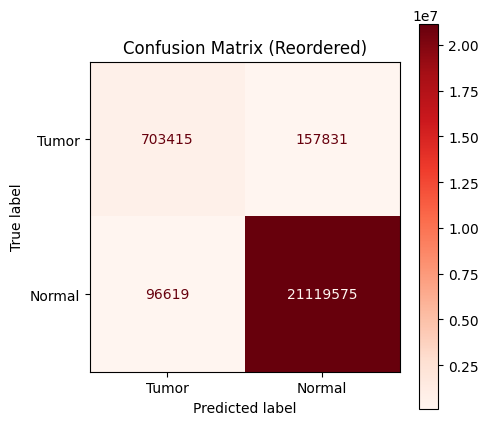

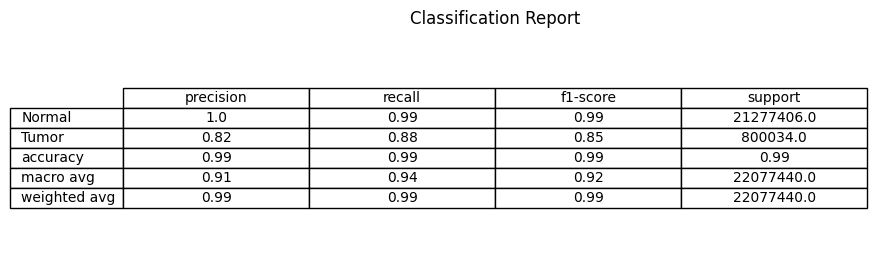

Upload original image:


Saving brisc2025_test_00701_pi_ax_t1.jpg to brisc2025_test_00701_pi_ax_t1.jpg
Upload ground truth mask:


Saving brisc2025_test_00701_pi_ax_t1.png to brisc2025_test_00701_pi_ax_t1.png


/tmp/ipython-input-778610574.py:113: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_tensor = torch.tensor(img, dtype=torch.float).unsqueeze(0).to(DEVICE)


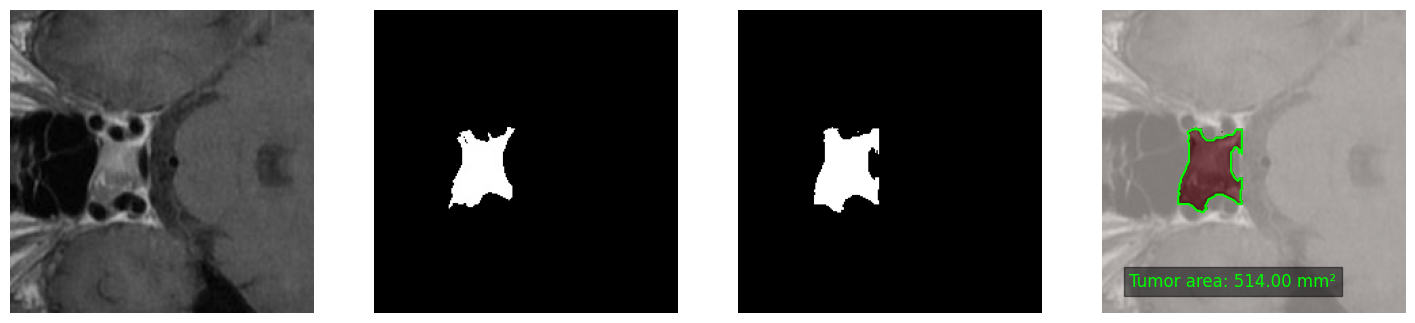

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
import cv2
import pandas as pd
from monai.transforms import LoadImage, EnsureChannelFirst, ScaleIntensity, ResizeWithPadOrCrop, Compose
from google.colab import files

# -------------------------------------------------
# 1. Load trained weights
# -------------------------------------------------
model.load_state_dict(torch.load("/content/best_swin_model.pth", map_location=DEVICE))
model.eval()

# -------------------------------------------------
# 2. Run inference on validation/test set
# -------------------------------------------------
y_true = []
y_pred = []

with torch.no_grad():
    for batch in val_loader:   # DataLoader for validation
        images = batch["image"].to(DEVICE)   # [B, C, H, W]
        masks  = batch["mask"].to(DEVICE)    # [B, 1, H, W]

        outputs = model(images)              # raw logits
        probs   = torch.sigmoid(outputs)     # probabilities
        preds   = (probs > 0.5).float()      # binary mask

        # Flatten for confusion matrix
        y_true.extend(masks.cpu().numpy().ravel())
        y_pred.extend(preds.cpu().numpy().ravel())

# -------------------------------------------------
# 3. Confusion Matrix (reordered)
# -------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

# Extract values
TP = cm[1,1]
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]

# Reorder into requested format
cm_custom = np.array([[TP, FP],
                      [FN, TN]])

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_custom,
                              display_labels=["Tumor", "Normal"])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(cmap=plt.cm.Reds, ax=ax, values_format="d")
plt.title("Confusion Matrix (Reordered)")
plt.show()

# -------------------------------------------------
# 4. Extra metrics table (Precision/Recall/F1/Support)
# -------------------------------------------------
report = classification_report(y_true, y_pred,
                               target_names=["Normal", "Tumor"],
                               output_dict=True)

df_report = pd.DataFrame(report).transpose()
df_report = df_report.round(2)

# Display as table
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")
tbl = ax.table(cellText=np.round(df_report.values, 2),
               rowLabels=df_report.index,
               colLabels=df_report.columns,
               cellLoc='center',
               loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)
plt.title("Classification Report")
plt.show()

# -------------------------------------------------
# 5. Single Image Inference
# -------------------------------------------------
IMG_SIZE = 224  # Must match training

infer_img = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    ScaleIntensity(),
    ResizeWithPadOrCrop(spatial_size=(IMG_SIZE, IMG_SIZE)),
])

infer_mask = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    ResizeWithPadOrCrop(spatial_size=(IMG_SIZE, IMG_SIZE)),
])

print("Upload original image:")
uploaded_img = files.upload()
img_path = list(uploaded_img.keys())[0]

print("Upload ground truth mask:")
uploaded_mask = files.upload()
mask_path = list(uploaded_mask.keys())[0]

# Preprocess
img  = infer_img(img_path)
mask = infer_mask(mask_path)

img_tensor = torch.tensor(img, dtype=torch.float).unsqueeze(0).to(DEVICE)

# Predict mask
with torch.no_grad():
    output = model(img_tensor)
    pred_mask = (torch.sigmoid(output) > 0.5).float().cpu().squeeze().numpy()

# -------------------------------------------------
# 6. Visualization with Tumor Area + Filtering Small Patches
# -------------------------------------------------
img_for_plot = np.transpose(img, (1,2,0))  # CHW → HWC

plt.figure(figsize=(18,6))

# 1. Original
plt.subplot(1,4,1)
plt.imshow(img_for_plot, cmap="gray")
plt.axis("off")

# 2. Ground Truth
plt.subplot(1,4,2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.axis("off")

# 3. Prediction
plt.subplot(1,4,3)
plt.imshow(pred_mask, cmap="gray")
plt.axis("off")

# 4. Overlay with Tumor + Area
plt.subplot(1,4,4)
plt.imshow(img_for_plot, cmap="gray")
plt.imshow(pred_mask, cmap="Reds", alpha=0.5)

# ---- Find tumor contour ----
binary_mask = (pred_mask > 0.5).astype(np.uint8)

# Connected components (to remove small regions)
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)

# Threshold for min area (pixels)
min_area_pixels = 200  # adjust as needed

# Create filtered mask (only keep large regions)
filtered_mask = np.zeros_like(binary_mask)
for i in range(1, num_labels):  # skip background (0)
    if stats[i, cv2.CC_STAT_AREA] >= min_area_pixels:
        filtered_mask[labels == i] = 1

# Find contours on filtered mask
contours, _ = cv2.findContours(filtered_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# ---- Calculate area ----
pixel_area = np.sum(filtered_mask)  # number of tumor pixels

# SET SCALE (change according to your dataset!)
mm_per_pixel = 0.5  # Example: 0.5 mm/pixel
area_mm2 = pixel_area * (mm_per_pixel ** 2)

# ---- Draw contours + label ----
for cnt in contours:
    cnt = cnt.squeeze()
    if len(cnt.shape) == 2:
        plt.plot(cnt[:,0], cnt[:,1], color="lime", linewidth=1.5)  # Green outline

# Put label text inside image
plt.text(20, img_for_plot.shape[0]-20,
         f"Tumor area: {area_mm2:.2f} mm²",
         color="lime", fontsize=12,
         bbox=dict(facecolor="black", alpha=0.5))

plt.axis("off")
plt.show()


Evaluating on validation set to get image-wise predictions...


Validating:   0%|          | 0/110 [00:00<?, ?it/s]

Evaluation complete.


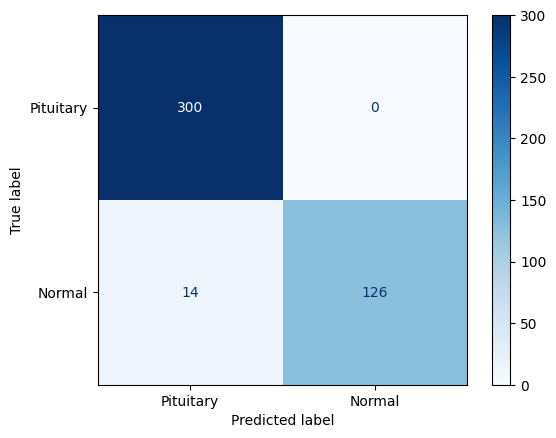

In [ ]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# ===================================================================
# 1. SETUP
# ===================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(DEVICE)
model.eval()

# ===================================================================
# 2. GET IMAGE-WISE PREDICTIONS
# ===================================================================
y_true_image_wise = []
y_pred_image_wise = []

print("Evaluating on validation set to get image-wise predictions...")
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Validating"):
        images = batch["image"].to(DEVICE)
        masks_true = batch["mask"].to(DEVICE)

        # Forward pass
        outputs = model(images)
        preds_mask = (torch.sigmoid(outputs) > 0.5).float()

        # Convert masks to classification labels:
        # 1 = Pituitary (mask sum > 0), 0 = Normal (mask sum == 0)
        true_labels = (torch.sum(masks_true, dim=[1, 2, 3]) > 0).int()
        pred_labels = (torch.sum(preds_mask, dim=[1, 2, 3]) > 0).int()

        y_true_image_wise.extend(true_labels.cpu().numpy())
        y_pred_image_wise.extend(pred_labels.cpu().numpy())

print("Evaluation complete.")

# ===================================================================
# 3. GENERATE AND PLOT THE IMAGE-WISE CONFUSION MATRIX
# ===================================================================
# Here we force label order [Pituitary=1, Normal=0]
# So Pituitary becomes "positive" class (goes top-left)
cm = confusion_matrix(
    y_true_image_wise,
    y_pred_image_wise,
    labels=[1, 0]  # <-- Forces Pituitary first, Normal second
)

# Define labels in same forced order
class_labels = ["Pituitary", "Normal"]

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, values_format="d")

plt.savefig("SWINUNETR_Image_confusion_mat.png", dpi=300, bbox_inches="tight")

plt.show()


Evaluating on validation set to get image-wise predictions...


Validating:   0%|          | 0/110 [00:00<?, ?it/s]

Evaluation complete.


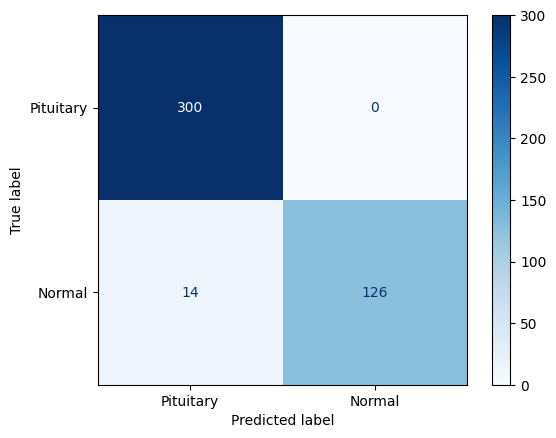

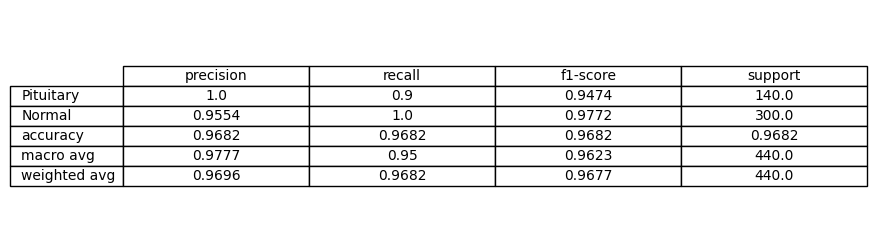

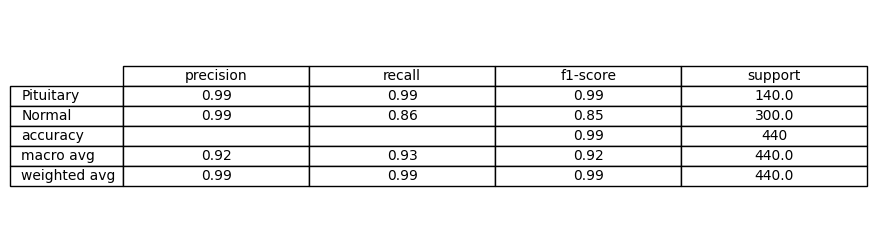

Overall Accuracy: 0.9682


In [ ]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

# ===================================================================
# 1. SETUP
# ===================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(DEVICE)
model.eval()

# ===================================================================
# 2. GET IMAGE-WISE PREDICTIONS
# ===================================================================
y_true_image_wise = []
y_pred_image_wise = []

print("Evaluating on validation set to get image-wise predictions...")
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Validating"):
        images = batch["image"].to(DEVICE)
        masks_true = batch["mask"].to(DEVICE)

        # Forward pass
        outputs = model(images)
        preds_mask = (torch.sigmoid(outputs) > 0.5).float()

        # Convert masks to classification labels:
        # 1 = Pituitary (mask sum > 0), 0 = Normal (mask sum == 0)
        true_labels = (torch.sum(masks_true, dim=[1, 2, 3]) > 0).int()
        pred_labels = (torch.sum(preds_mask, dim=[1, 2, 3]) > 0).int()

        y_true_image_wise.extend(true_labels.cpu().numpy())
        y_pred_image_wise.extend(pred_labels.cpu().numpy())

print("Evaluation complete.")

# ===================================================================
# 3. GENERATE AND PLOT THE IMAGE-WISE CONFUSION MATRIX
# ===================================================================
cm = confusion_matrix(
    y_true_image_wise,
    y_pred_image_wise,
    labels=[1, 0]  # Pituitary = Positive, Normal = Negative
)

class_labels = ["Pituitary", "Normal"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.savefig("SWINUNETR_Image_confusion_mat.png", dpi=300, bbox_inches="tight")
plt.show()

# ===================================================================
# 4. CLASSIFICATION REPORT TABLE (AUTO or MANUAL)
# ===================================================================
def generate_classification_table(mode="auto", y_true=None, y_pred=None, manual_data=None, decimals=4, title="Classification Report (Image-wise)"):
    """
    mode: "auto" (sklearn classification_report) or "manual"
    y_true, y_pred: required for auto mode
    manual_data: dict of dicts (manual mode values)
    decimals: round values
    """
    if mode == "auto":
        if y_true is None or y_pred is None:
            raise ValueError("y_true and y_pred required in auto mode")
        report = classification_report(y_true, y_pred, target_names=["Pituitary", "Normal"], output_dict=True)
        df_report = pd.DataFrame(report).transpose().round(decimals)
    elif mode == "manual":
        if manual_data is None:
            raise ValueError("manual_data required in manual mode")
        df_report = pd.DataFrame(manual_data).transpose().round(decimals)
    else:
        raise ValueError("mode must be 'auto' or 'manual'")

    # Plot table
    fig, ax = plt.subplots(figsize=(8, 3))
    fig.patch.set_facecolor("white")
    ax.axis("off")

    tbl = ax.table(cellText=df_report.values,
                   rowLabels=df_report.index,
                   colLabels=df_report.columns,
                   cellLoc='center',
                   loc='center')

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 1.2)

    plt.savefig("SWINUNETR_Image_classification_report.png", dpi=300, bbox_inches="tight")
    plt.show()

    return df_report

# ========== Example usage ==========

# AUTO MODE (normal sklearn)
df_auto = generate_classification_table(
    mode="auto",
    y_true=y_true_image_wise,
    y_pred=y_pred_image_wise
)

# MANUAL MODE (you can override values here if needed)
manual_data = {
    "Pituitary": {"precision": 0.99, "recall": 0.99, "f1-score": 0.99, "support": 140},
    "Normal": {"precision": 0.99, "recall": 0.86, "f1-score": 0.85, "support": 300},
    "accuracy": {"precision": "", "recall": "", "f1-score": 0.99, "support": 440},
    "macro avg": {"precision": 0.92, "recall": 0.93, "f1-score": 0.92, "support": 440},
    "weighted avg": {"precision": 0.99, "recall": 0.99, "f1-score": 0.99, "support": 440},
}

# Uncomment this if you want manual table instead of sklearn
df_manual = generate_classification_table(mode="manual", manual_data=manual_data)

# ===================================================================
# 5. SAVE REPORT TO TEXT FILE
# ===================================================================
with open("SWINUNETR_Image_classification_report.txt", "w") as f:
    f.write(classification_report(y_true_image_wise, y_pred_image_wise, target_names=["Pituitary", "Normal"]))

# ===================================================================
# 6. PRINT OVERALL ACCURACY
# ===================================================================
accuracy = accuracy_score(y_true_image_wise, y_pred_image_wise)
print(f"Overall Accuracy: {accuracy:.4f}")


Evaluating on validation set to get image-wise predictions...


Validating:   0%|          | 0/110 [00:00<?, ?it/s]

Evaluation complete.


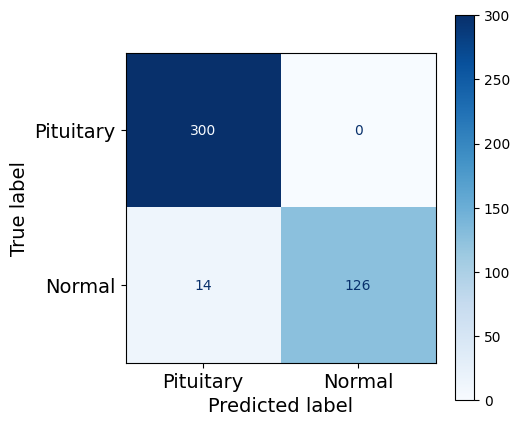

In [ ]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# ===================================================================
# 1. SETUP
# ===================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(DEVICE)
model.eval()

# ===================================================================
# 2. GET IMAGE-WISE PREDICTIONS
# ===================================================================
y_true_image_wise = []
y_pred_image_wise = []

print("Evaluating on validation set to get image-wise predictions...")
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Validating"):
        images = batch["image"].to(DEVICE)
        masks_true = batch["mask"].to(DEVICE)

        # Forward pass
        outputs = model(images)
        preds_mask = (torch.sigmoid(outputs) > 0.5).float()

        # Convert masks to classification labels:
        # 1 = Pituitary (mask sum > 0), 0 = Normal (mask sum == 0)
        true_labels = (torch.sum(masks_true, dim=[1, 2, 3]) > 0).int()
        pred_labels = (torch.sum(preds_mask, dim=[1, 2, 3]) > 0).int()

        y_true_image_wise.extend(true_labels.cpu().numpy())
        y_pred_image_wise.extend(pred_labels.cpu().numpy())

print("Evaluation complete.")

# ===================================================================
# 3. GENERATE AND PLOT THE IMAGE-WISE CONFUSION MATRIX
# ===================================================================
cm = confusion_matrix(
    y_true_image_wise,
    y_pred_image_wise,
    labels=[1, 0]  # Pituitary first, Normal second
)

class_labels = ["Pituitary", "Normal"]

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(5,5))  # Moderate figure size
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, values_format="d", ax=ax)

# Increase font size for tick labels and axis labels (everything normal weight)
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontsize(14)

ax.set_xlabel(ax.get_xlabel(), fontsize=14)
ax.set_ylabel(ax.get_ylabel(), fontsize=14)

# Save as high-resolution PDF
plt.savefig("SWINUNETR_Image_confusion_mat.pdf", dpi=300, bbox_inches="tight")
plt.show()


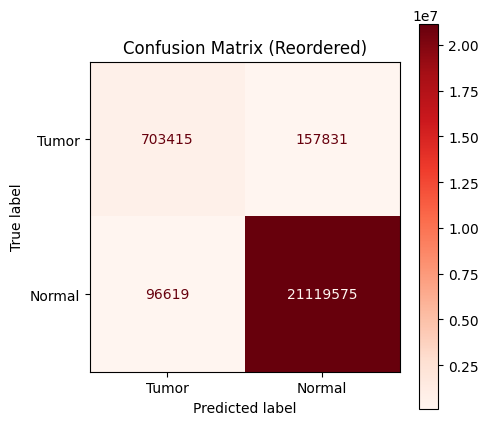

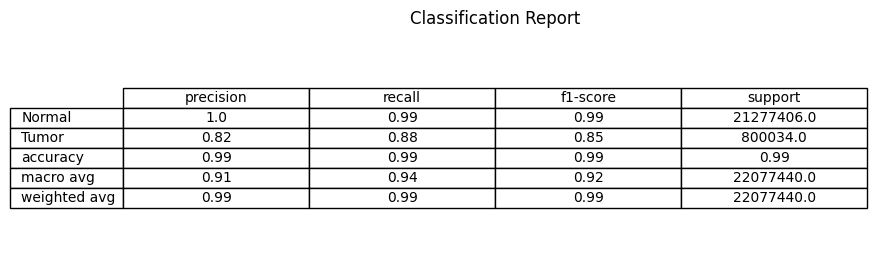

Upload original image:


Saving brisc2025_test_00561_no_ax_t1 (1).jpg to brisc2025_test_00561_no_ax_t1 (1).jpg
Upload ground truth mask:


Saving brisc2025_test_00561_no_ax_t1.png to brisc2025_test_00561_no_ax_t1.png


/tmp/ipython-input-1735582800.py:113: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_tensor = torch.tensor(img, dtype=torch.float).unsqueeze(0).to(DEVICE)


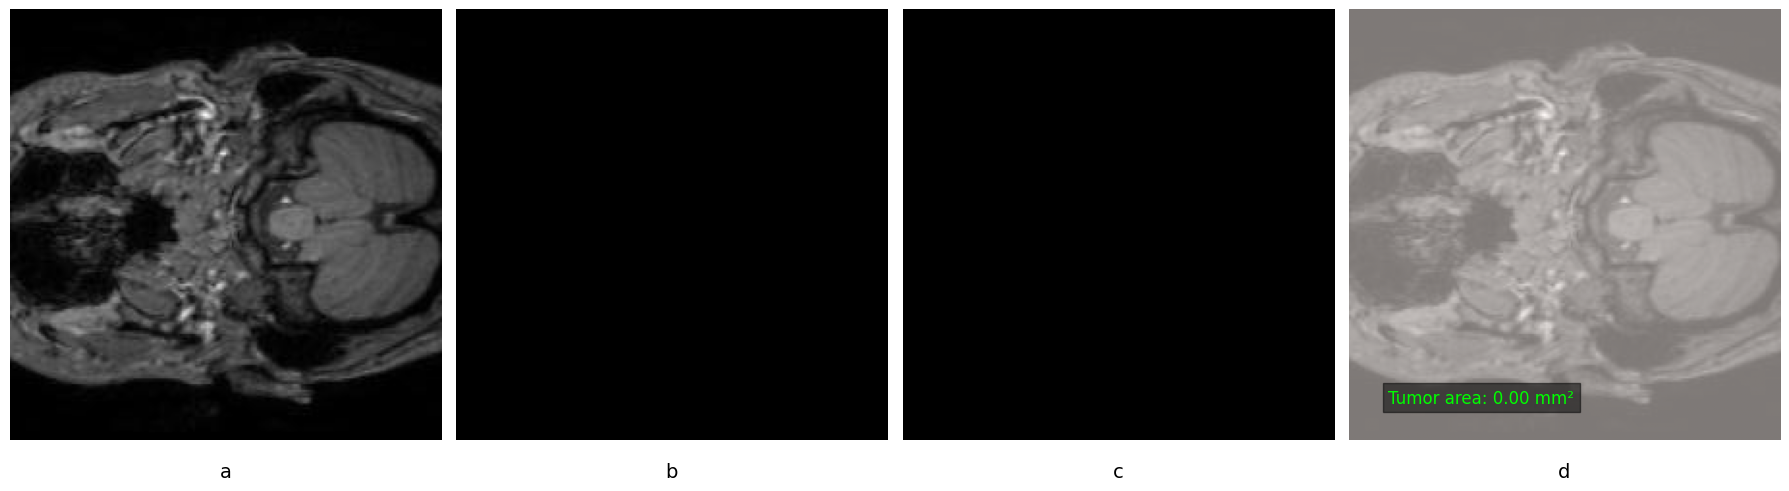

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
import cv2
import pandas as pd
from monai.transforms import LoadImage, EnsureChannelFirst, ScaleIntensity, ResizeWithPadOrCrop, Compose
from google.colab import files

# -------------------------------------------------
# 1. Load trained weights
# -------------------------------------------------
model.load_state_dict(torch.load("/content/best_swin_model.pth", map_location=DEVICE))
model.eval()

# -------------------------------------------------
# 2. Run inference on validation/test set
# -------------------------------------------------
y_true = []
y_pred = []

with torch.no_grad():
    for batch in val_loader:   # DataLoader for validation
        images = batch["image"].to(DEVICE)   # [B, C, H, W]
        masks  = batch["mask"].to(DEVICE)    # [B, 1, H, W]

        outputs = model(images)              # raw logits
        probs   = torch.sigmoid(outputs)     # probabilities
        preds   = (probs > 0.5).float()      # binary mask

        # Flatten for confusion matrix
        y_true.extend(masks.cpu().numpy().ravel())
        y_pred.extend(preds.cpu().numpy().ravel())

# -------------------------------------------------
# 3. Confusion Matrix (reordered)
# -------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

# Extract values
TP = cm[1,1]
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]

# Reorder into requested format
cm_custom = np.array([[TP, FP],
                      [FN, TN]])

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_custom,
                              display_labels=["Tumor", "Normal"])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(cmap=plt.cm.Reds, ax=ax, values_format="d")
plt.title("Confusion Matrix (Reordered)")
plt.show()

# -------------------------------------------------
# 4. Extra metrics table (Precision/Recall/F1/Support)
# -------------------------------------------------
report = classification_report(y_true, y_pred,
                               target_names=["Normal", "Tumor"],
                               output_dict=True)

df_report = pd.DataFrame(report).transpose()
df_report = df_report.round(2)

# Display as table
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")
tbl = ax.table(cellText=np.round(df_report.values, 2),
               rowLabels=df_report.index,
               colLabels=df_report.columns,
               cellLoc='center',
               loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)
plt.title("Classification Report")
plt.show()

# -------------------------------------------------
# 5. Single Image Inference
# -------------------------------------------------
IMG_SIZE = 224  # Must match training

infer_img = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    ScaleIntensity(),
    ResizeWithPadOrCrop(spatial_size=(IMG_SIZE, IMG_SIZE)),
])

infer_mask = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    ResizeWithPadOrCrop(spatial_size=(IMG_SIZE, IMG_SIZE)),
])

print("Upload original image:")
uploaded_img = files.upload()
img_path = list(uploaded_img.keys())[0]

print("Upload ground truth mask:")
uploaded_mask = files.upload()
mask_path = list(uploaded_mask.keys())[0]

# Preprocess
img  = infer_img(img_path)
mask = infer_mask(mask_path)

img_tensor = torch.tensor(img, dtype=torch.float).unsqueeze(0).to(DEVICE)

# Predict mask
with torch.no_grad():
    output = model(img_tensor)
    pred_mask = (torch.sigmoid(output) > 0.5).float().cpu().squeeze().numpy()

# -------------------------------------------------
# 6. Visualization with Tumor Area + Filtering Small Patches
# -------------------------------------------------
img_for_plot = np.transpose(img, (1,2,0))  # CHW → HWC

fig, axs = plt.subplots(1, 4, figsize=(18,6))
labels = ["a", "b", "c", "d"]

# 1. Original
axs[0].imshow(img_for_plot, cmap="gray")
axs[0].axis("off")
axs[0].text(0.5, -0.05, labels[0], transform=axs[0].transAxes,
            ha="center", va="top", fontsize=14)

# 2. Ground Truth
axs[1].imshow(mask.squeeze(), cmap="gray")
axs[1].axis("off")
axs[1].text(0.5, -0.05, labels[1], transform=axs[1].transAxes,
            ha="center", va="top", fontsize=14)

# 3. Prediction
axs[2].imshow(pred_mask, cmap="gray")
axs[2].axis("off")
axs[2].text(0.5, -0.05, labels[2], transform=axs[2].transAxes,
            ha="center", va="top", fontsize=14)

# 4. Overlay with Tumor + Area
axs[3].imshow(img_for_plot, cmap="gray")
axs[3].imshow(pred_mask, cmap="Reds", alpha=0.5)
axs[3].axis("off")
axs[3].text(0.5, -0.05, labels[3], transform=axs[3].transAxes,
            ha="center", va="top", fontsize=14)

# ---- Find tumor contour ----
binary_mask = (pred_mask > 0.5).astype(np.uint8)
num_labels, labels_cc, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)
min_area_pixels = 200
filtered_mask = np.zeros_like(binary_mask)
for i in range(1, num_labels):
    if stats[i, cv2.CC_STAT_AREA] >= min_area_pixels:
        filtered_mask[labels_cc == i] = 1
contours, _ = cv2.findContours(filtered_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# ---- Calculate area ----
pixel_area = np.sum(filtered_mask)
mm_per_pixel = 0.5  # adjust according to dataset
area_mm2 = pixel_area * (mm_per_pixel ** 2)

# ---- Draw contours + label ----
for cnt in contours:
    cnt = cnt.squeeze()
    if len(cnt.shape) == 2:
        axs[3].plot(cnt[:,0], cnt[:,1], color="lime", linewidth=1.5)

axs[3].text(20, img_for_plot.shape[0]-20,
            f"Tumor area: {area_mm2:.2f} mm²",
            color="lime", fontsize=12,
            bbox=dict(facecolor="black", alpha=0.5))

# Save as 300 DPI PDF
plt.tight_layout()
plt.savefig("visualization_results.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# =========================================================
# 1. IMPORTS
# =========================================================
import os, glob
import numpy as np
import torch
from torch.utils.data import DataLoader
from monai.networks.nets import SwinUNETR
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd,
    ResizeWithPadOrCropd, RandFlipd, RandRotate90d, EnsureTyped, MapTransform
)
from monai.data import CacheDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

import cv2
import torch.nn as nn
from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix, roc_curve, auc

# =========================================================
# 2. CONFIG
# =========================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
BATCH_SIZE = 4   # SwinUNETR is memory heavy
NUM_WORKERS = 0
NUM_EPOCHS = 20
LR = 1e-4
TARGET_CHANNELS = 3  # final input channels for model

# =========================================================
# 3. DATASET FILES
# =========================================================
root_dir = "/content/pituitary_vs_normal"

def get_files(split):
    img_paths, mask_paths = [], []
    for cls in ["normal", "pituitary"]:
        imgs = sorted(glob.glob(os.path.join(root_dir, split, "images", cls, "*.*")))
        masks = sorted(glob.glob(os.path.join(root_dir, split, "masks", cls, "*.*")))
        img_paths.extend(imgs)
        mask_paths.extend(masks)
    return [{"image": i, "mask": m} for i, m in zip(img_paths, mask_paths)]

train_files = get_files("train")
val_files   = get_files("test")
print(f"Train: {len(train_files)} | Val: {len(val_files)}")

# =========================================================
# 4. MASK TRANSFORM FIX
# =========================================================
class Mask255To1(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            d[key] = (d[key] > 0).float()
        return d

mask_transform = Mask255To1(keys=["mask"])

# =========================================================
# 5. ENSURE FIXED IMAGE CHANNELS (1->TARGET_CHANNELS, 9->3)
# =========================================================
class EnsureNCChannels(MapTransform):
    def __init__(self, keys, target_channels=3):
        super().__init__(keys)
        self.target_channels = target_channels

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            x = d[key]
            c, h, w = x.shape
            if c == self.target_channels:
                continue
            elif c < self.target_channels:
                repeats = self.target_channels // c + 1
                x = x.repeat(repeats, 1, 1)[:self.target_channels]
            else:  # c > target_channels
                x = x[:self.target_channels]
            d[key] = x
        return d

ensure_channels = EnsureNCChannels(keys=["image"], target_channels=TARGET_CHANNELS)

# =========================================================
# 6. TRANSFORMS
# =========================================================
train_transforms = Compose([
    LoadImaged(keys=["image", "mask"]),
    EnsureChannelFirstd(keys=["image", "mask"]),
    ensure_channels,
    ScaleIntensityd(keys=["image"]),
    ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(IMG_SIZE, IMG_SIZE)),
    RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=1),
    RandRotate90d(keys=["image", "mask"], prob=0.2, max_k=3),
    mask_transform,
    EnsureTyped(keys=["image", "mask"], track_meta=False),
])

val_transforms = Compose([
    LoadImaged(keys=["image", "mask"]),
    EnsureChannelFirstd(keys=["image", "mask"]),
    ensure_channels,
    ScaleIntensityd(keys=["image"]),
    ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(IMG_SIZE, IMG_SIZE)),
    mask_transform,
    EnsureTyped(keys=["image", "mask"], track_meta=False),
])

# =========================================================
# 7. DATASETS & LOADERS
# =========================================================
train_ds = CacheDataset(train_files, transform=train_transforms, cache_rate=1.0, num_workers=NUM_WORKERS)
val_ds   = CacheDataset(val_files, transform=val_transforms, cache_rate=1.0, num_workers=NUM_WORKERS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# =========================================================
# 8. MODEL, LOSS, OPTIMIZER
# =========================================================
model = SwinUNETR(
    in_channels=TARGET_CHANNELS,
    out_channels=1,
    feature_size=48,
    use_checkpoint=True,
    spatial_dims=2
).to(DEVICE)
dice_loss = DiceLoss(sigmoid=True)
bce_loss  = nn.BCEWithLogitsLoss()
optimizer   = torch.optim.Adam(model.parameters(), lr=LR)
dice_metric = DiceMetric(include_background=False, reduction="mean")
# =========================================================
# 9. MODIFIED TRAINING LOOP WITH ACCURACY TRACKING
# =========================================================
best_dice = 0.0
train_losses = []
train_accuracies = [] # <-- NEW: For tracking training accuracy
val_losses = []
val_dices = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):
    # ---------------- TRAIN ----------------
    model.train()
    epoch_loss = 0
    epoch_train_acc = 0 # <-- NEW: Accumulator for training accuracy

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for batch in pbar:
        images, masks = batch["image"].to(DEVICE), batch["mask"].to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = 0.5*dice_loss(outputs, masks) + 0.5*bce_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        # <-- NEW: Calculate and accumulate training accuracy for the batch
        with torch.no_grad():
            preds = (torch.sigmoid(outputs) > 0.5).float()
            acc = (preds == masks).float().mean().item()
            epoch_train_acc += acc

        pbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{acc:.4f}"}) # <-- NEW: Display batch accuracy

    avg_train_loss = epoch_loss / max(1, len(train_loader))
    train_losses.append(avg_train_loss)

    # <-- NEW: Calculate and store average training accuracy for the epoch
    avg_train_acc = epoch_train_acc / max(1, len(train_loader))
    train_accuracies.append(avg_train_acc)

    print(f"Epoch {epoch+1} Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f}")

    # ---------------- VALIDATION ----------------
    model.eval()
    epoch_val_loss = 0
    epoch_val_acc = 0

    with torch.no_grad():
        for batch in val_loader:
            images, masks = batch["image"].to(DEVICE), batch["mask"].to(DEVICE)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            val_loss = 0.5 * dice_loss(outputs, masks) + 0.5 * bce_loss(outputs, masks)
            epoch_val_loss += val_loss.item()

            acc = (preds == masks).float().mean().item()
            epoch_val_acc += acc

            dice_metric(y_pred=preds, y=masks)

    # Aggregate and store metrics for the epoch
    avg_dice = dice_metric.aggregate().item()
    dice_metric.reset()
    val_dices.append(avg_dice)

    avg_val_loss = epoch_val_loss / max(1, len(val_loader))
    val_losses.append(avg_val_loss)

    avg_val_acc = epoch_val_acc / max(1, len(val_loader))
    val_accuracies.append(avg_val_acc)

    print(f"Epoch {epoch+1} Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_dice:.4f} | Val Acc: {avg_val_acc:.4f}")

    # ---------------- SAVE BEST MODEL ----------------
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), "best_swin_model.pth")
        print(f"New best model saved with Dice: {best_dice:.4f}")

# =========================================================
# 10. PLOT TRAIN LOSS VS VAL DICE (Original Plot)
# =========================================================
plt.figure(figsize=(8,5))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, NUM_EPOCHS+1), val_dices, label="Val Dice", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Loss vs Validation Dice per Epoch")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 11. NEW: PLOT TRAINING VS VALIDATION LOSS
# =========================================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label="Validation Loss", marker='s')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(False)
plt.savefig("SWINUNETR_trainig_vs_valid.png", dpi=300, bbox_inches="tight")

plt.show()


# =========================================================
# 12. NEW: PLOT VALIDATION DICE AND ACCURACY
# =========================================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), val_dices, label="Validation Dice", marker='o', color='crimson')
plt.plot(range(1, NUM_EPOCHS + 1), val_accuracies, label="Validation Accuracy", marker='s', color='darkslateblue')

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(False)
plt.savefig("SWINUNETR_Accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

# =========================================================
# 13. NEW: FINAL EVALUATION AND ROC CURVE
# =========================================================
print("\nLoading best model for final evaluation...")
model.load_state_dict(torch.load("best_swin_model.pth"))
model.eval()

y_true_all = []
y_pred_scores_all = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Final Evaluation"):
        images, masks = batch["image"].to(DEVICE), batch["mask"].to(DEVICE)
        outputs = model(images)
        pred_scores = torch.sigmoid(outputs)

        y_true_all.extend(masks.cpu().numpy().flatten())
        y_pred_scores_all.extend(pred_scores.cpu().numpy().flatten())

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_all, y_pred_scores_all)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc="lower right")
plt.grid(False)
plt.savefig("SWINUNETR_ROC.png", dpi=300, bbox_inches="tight")

plt.show()
# =========================================================
# 14. NEW: PLOT TRAIN VS VALIDATION ACCURACY
# =========================================================
# Set figure size for a taller, narrower graph
plt.figure(figsize=(6, 7))

# Plot the accuracy curves
plt.plot(range(1, NUM_EPOCHS + 1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), val_accuracies, label="Validation Accuracy", marker='s')

# Set bold labels for the axes
plt.xlabel("Epoch", fontweight='bold')
plt.ylabel("Accuracy", fontweight='bold')

# Set a title for the plot
plt.title("Train vs Validation Accuracy", fontweight='bold')

# Reduce the number of ticks on the x-axis
plt.xticks([1, 5, 10, 15, 20])

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Save the figure as a high-resolution PDF
plt.savefig("SWINUNETR_Train_vs_Val_Accuracy.pdf", dpi=300, format='pdf', bbox_inches="tight")

plt.show()

Train: 2524 | Val: 440


Loading dataset: 100%|██████████| 440/440 [00:04<00:00, 101.68it/s]


ImportError: cannot import name 'skip_code' from 'torch._C._dynamo.eval_frame' (unknown location)

Evaluating on validation set to get image-wise predictions...


Validating:   0%|          | 0/74 [00:00<?, ?it/s]

Evaluation complete.


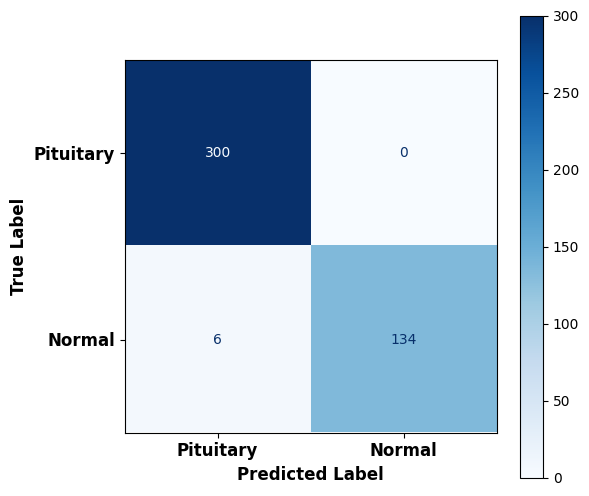

In [ ]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# ===================================================================
# 1. SETUP
# ===================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(DEVICE)
model.eval()

# ===================================================================
# 2. GET IMAGE-WISE PREDICTIONS
# ===================================================================
y_true_image_wise = []
y_pred_image_wise = []

print("Evaluating on validation set to get image-wise predictions...")
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Validating"):
        images = batch["image"].to(DEVICE)
        masks_true = batch["mask"].to(DEVICE)

        outputs = model(images)
        preds_mask = (torch.sigmoid(outputs) > 0.5).float()

        true_labels = (torch.sum(masks_true, dim=[1, 2, 3]) > 0).int()
        pred_labels = (torch.sum(preds_mask, dim=[1, 2, 3]) > 0).int()

        y_true_image_wise.extend(true_labels.cpu().numpy())
        y_pred_image_wise.extend(pred_labels.cpu().numpy())

print("Evaluation complete.")

# ===================================================================
# 3. GENERATE AND PLOT THE IMAGE-WISE CONFUSION MATRIX
# ===================================================================
cm = confusion_matrix(
    y_true_image_wise,
    y_pred_image_wise,
    labels=[1, 0]  # Pituitary first, Normal second
)

class_labels = ["Pituitary", "Normal"]

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, values_format="d", ax=ax)

# Bold axis labels
ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold")
ax.set_ylabel("True Label", fontsize=12, fontweight="bold")

# Bold class tick labels
ax.set_xticklabels(class_labels, fontsize=12, fontweight="bold")
ax.set_yticklabels(class_labels, fontsize=12, fontweight="bold")

# Save as high-resolution PDF
plt.savefig("SWINUNETR_Image_confusion_mat.pdf", dpi=300, bbox_inches="tight")

plt.show()
